# 01 — Import and Preview RGC Images

Load cropped retinal ganglion cell images from `../data/cropped/`, inspect image metadata, and export a contact sheet.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.style.use("default")

In [2]:
data_dir = Path("../data/cropped")
output_dir = Path("../outputs/rgc_image_analysis")
fig_dir = output_dir / "figures"

output_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

image_paths = sorted(
    list(data_dir.glob("*.tif")) +
    list(data_dir.glob("*.tiff")) +
    list(data_dir.glob("*.png")) +
    list(data_dir.glob("*.jpg")) +
    list(data_dir.glob("*.jpeg"))
)

print("Image folder:", data_dir.resolve())
print("Number of images found:", len(image_paths))

for path in image_paths[:10]:
    print(path.name)

Image folder: /home/jg/Desktop/Data_Science_Tasks/data/cropped
Number of images found: 45
cropped0.tif
cropped1.tif
cropped10.tif
cropped11.tif
cropped12.tif
cropped13.tif
cropped14.tif
cropped15.tif
cropped16.tif
cropped17.tif


In [3]:
image_records = []

for path in image_paths:
    img = Image.open(path)
    arr = np.array(img)

    image_records.append({
        "filename": path.name,
        "path": str(path),
        "height": arr.shape[0],
        "width": arr.shape[1],
        "ndim": arr.ndim,
        "dtype": str(arr.dtype),
        "min_intensity": float(np.nanmin(arr)),
        "max_intensity": float(np.nanmax(arr)),
        "mean_intensity": float(np.nanmean(arr)),
        "std_intensity": float(np.nanstd(arr)),
    })

image_inventory = pd.DataFrame(image_records)
display(image_inventory)

inventory_path = output_dir / "rgc_image_inventory.csv"
image_inventory.to_csv(inventory_path, index=False)

print("Saved inventory:")
print(inventory_path)

,filename,path,height,width,ndim,dtype,min_intensity,max_intensity,mean_intensity,std_intensity
0,cropped0.tif,../data/cropped/cropped0.tif,512,512,2,>u2,132.0,3645.0,667.280510,288.812970
1,cropped1.tif,../data/cropped/cropped1.tif,512,512,2,>u2,11.0,3244.0,568.941177,363.127597
2,cropped10.tif,../data/cropped/cropped10.tif,512,512,2,>u2,6.0,3505.0,648.217060,497.915712
3,cropped11.tif,../data/cropped/cropped11.tif,512,512,2,>u2,222.0,4524.0,592.410511,450.415426
4,cropped12.tif,../data/cropped/cropped12.tif,512,512,2,>u2,129.0,4027.0,434.024525,423.994630
5,cropped13.tif,../data/cropped/cropped13.tif,512,512,2,>u2,12.0,4909.0,619.434856,483.269144
6,cropped14.tif,../data/cropped/cropped14.tif,512,512,2,>u2,12.0,3531.0,307.690857,443.863992
7,cropped15.tif,../data/cropped/cropped15.tif,512,512,2,>u2,154.0,3441.0,631.446312,372.674208
8,cropped16.tif,../data/cropped/cropped16.tif,512,512,2,>u2,313.0,4288.0,879.876232,420.278123
9,cropped17.tif,../data/cropped/cropped17.tif,512,512,2,>u2,0.0,3839.0,628.107845,639.083094


Saved inventory:
../outputs/rgc_image_analysis/rgc_image_inventory.csv


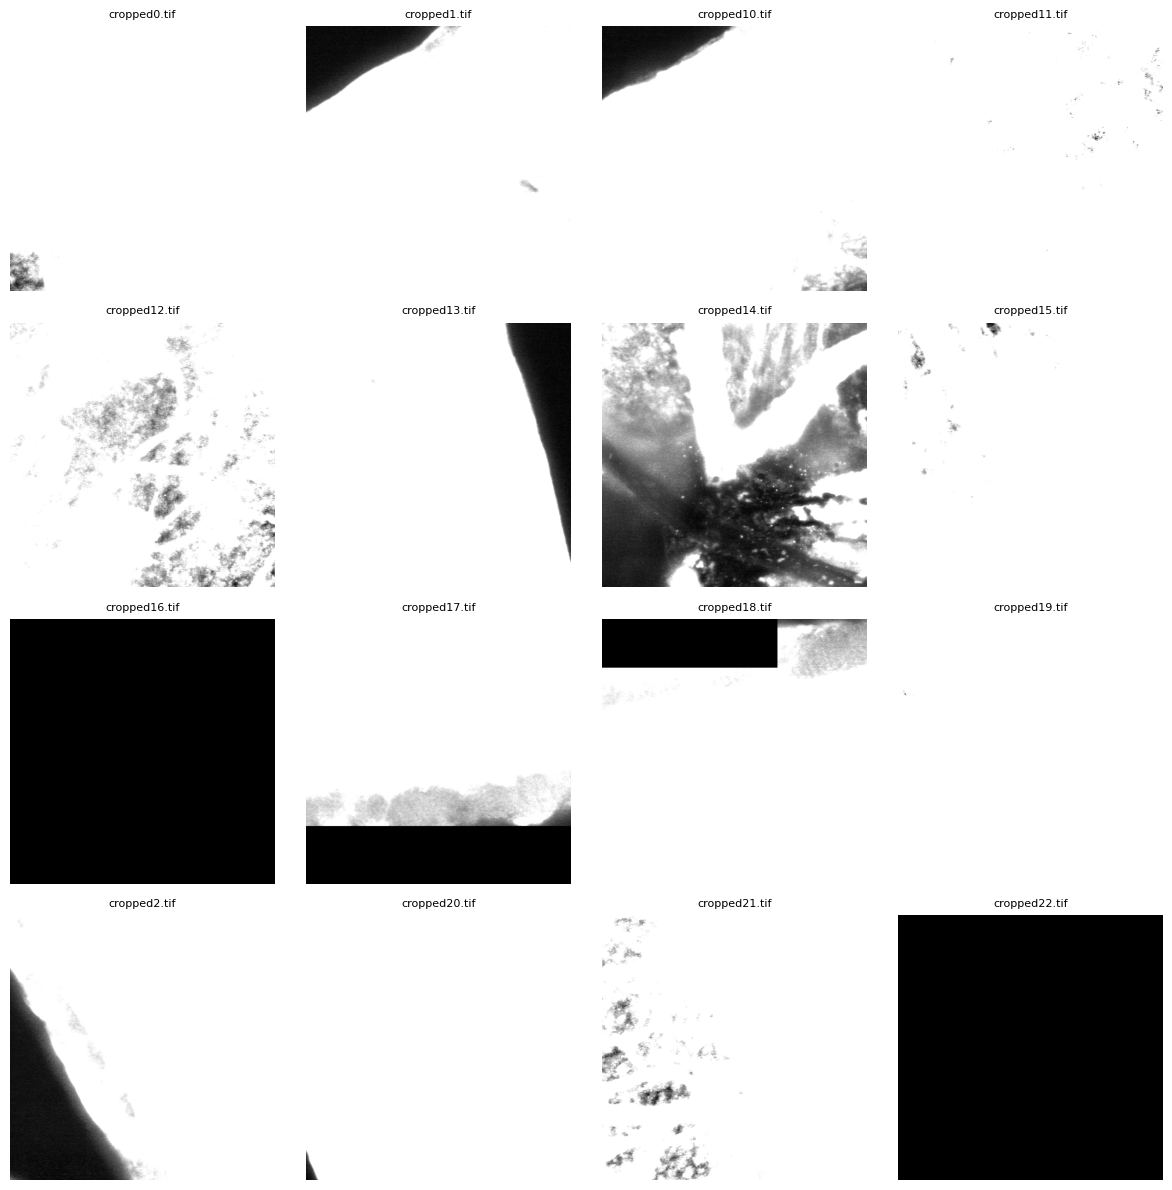

Saved contact sheet:
../outputs/rgc_image_analysis/figures/rgc_contact_sheet.tiff


In [4]:
n_show = min(len(image_paths), 16)
n_cols = 4
n_rows = int(np.ceil(n_show / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, idx in zip(axes, range(n_show)):
    path = image_paths[idx]
    img = Image.open(path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(path.name, fontsize=8)
    ax.axis("off")

for ax in axes[n_show:]:
    ax.axis("off")

plt.tight_layout()

contact_sheet_path = fig_dir / "rgc_contact_sheet.tiff"
fig.savefig(contact_sheet_path, dpi=300, format="tiff", bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved contact sheet:")
print(contact_sheet_path)